In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore
from scipy.stats import shapiro

plt.style.use("ggplot")

In [2]:
nav = pd.read_csv("../data/processed/02_nav_history.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices.csv")

In [3]:
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [4]:
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [5]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [6]:
nav["date"] = pd.to_datetime(nav["date"], format="mixed")

nav["nav"] = pd.to_numeric(nav["nav"], errors="coerce")

In [7]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

In [8]:
nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [9]:
risk_free_rate = 0.06

sharpe = nav.groupby("amfi_code")["daily_return"].agg(["mean", "std"])

sharpe["Sharpe Ratio"] = (
    (sharpe["mean"] - risk_free_rate / 252)
    / sharpe["std"]
)

sharpe.head()

,mean,std,Sharpe Ratio
amfi_code,,,
100016,0.000142,0.009164,-0.010529
100025,0.000170,0.002460,-0.027658
100033,0.001080,0.011929,0.070560
101206,0.000852,0.009177,0.066870
101207,0.000424,0.016251,0.011468


In [10]:
negative_returns = nav["daily_return"].copy()

negative_returns[negative_returns > 0] = 0

downside_std = (
    negative_returns.groupby(nav["amfi_code"])
    .std()
)

sortino = (
    sharpe["mean"] - risk_free_rate / 252
) / downside_std

sortino = sortino.rename("Sortino Ratio")

sortino.head()

amfi_code
100016   -0.018690
100025   -0.049242
100033    0.126921
101206    0.123009
101207    0.020133
Name: Sortino Ratio, dtype: float64

In [11]:
nav["rolling_max"] = (
    nav.groupby("amfi_code")["nav"]
    .cummax()
)

nav["drawdown"] = (
    nav["nav"] - nav["rolling_max"]
) / nav["rolling_max"]

max_drawdown = (
    nav.groupby("amfi_code")["drawdown"]
    .min()
)

max_drawdown.head()

amfi_code
100016   -0.247344
100025   -0.043083
100033   -0.162172
101206   -0.112916
101207   -0.354469
Name: drawdown, dtype: float64

In [12]:
var95 = (
    nav.groupby("amfi_code")["daily_return"]
    .quantile(0.05)
)

var95.head()

amfi_code
100016   -0.014364
100025   -0.003793
100033   -0.019034
101206   -0.013282
101207   -0.026021
Name: daily_return, dtype: float64

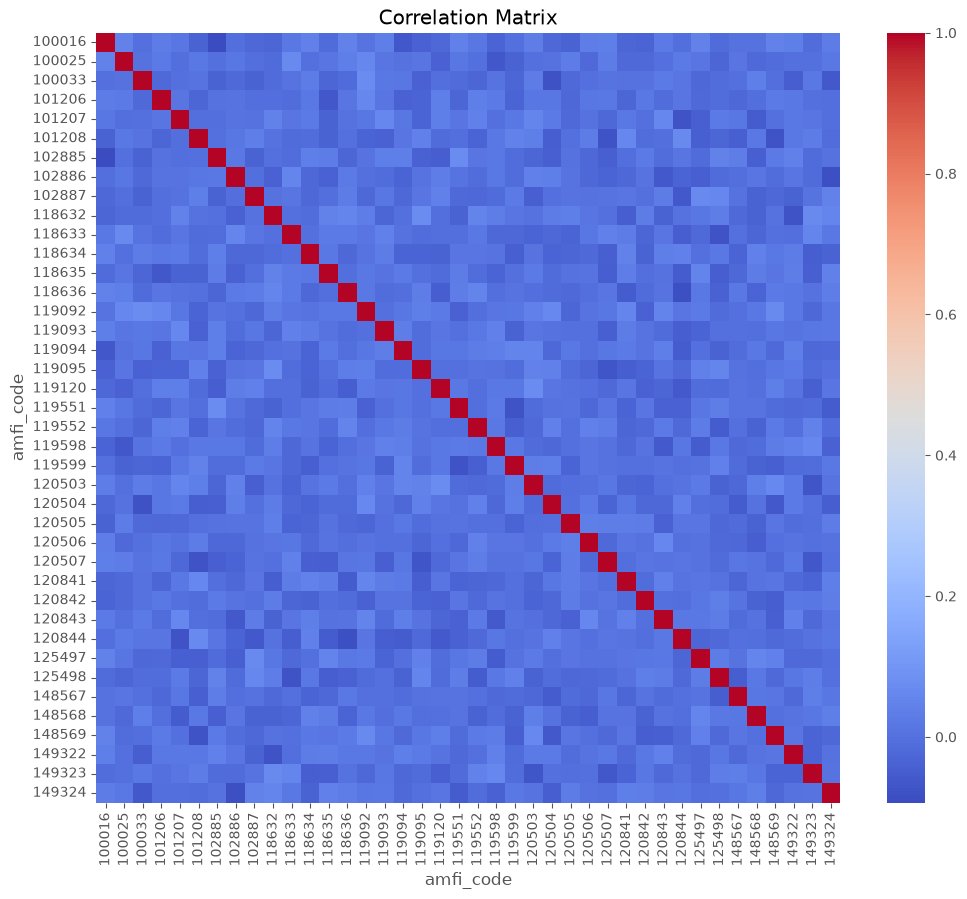

In [13]:
pivot = nav.pivot_table(
    index="date",
    columns="amfi_code",
    values="daily_return"
)

corr = pivot.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [14]:
returns = nav["daily_return"].dropna()

stat, p = shapiro(returns.sample(5000, random_state=42))

print("Statistic:", stat)

print("P-value:", p)

if p > 0.05:
    print("Data is Normally Distributed")
else:
    print("Data is NOT Normally Distributed")

Statistic: 0.9843988548120887
P-value: 4.434686388756741e-23
Data is NOT Normally Distributed


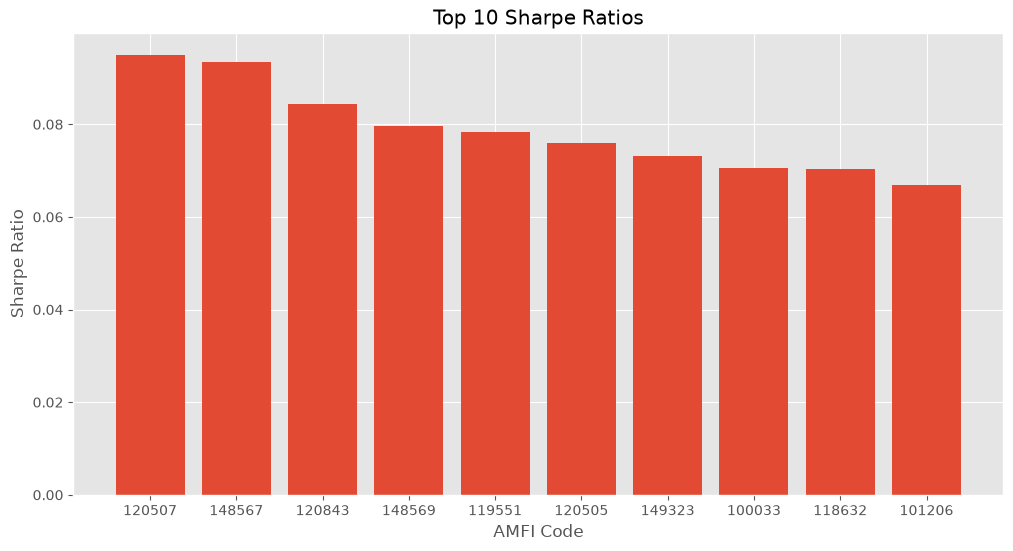

In [15]:
top = sharpe.sort_values(
    "Sharpe Ratio",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top.index.astype(str),
    top["Sharpe Ratio"]
)

plt.title("Top 10 Sharpe Ratios")

plt.xlabel("AMFI Code")

plt.ylabel("Sharpe Ratio")

plt.show()

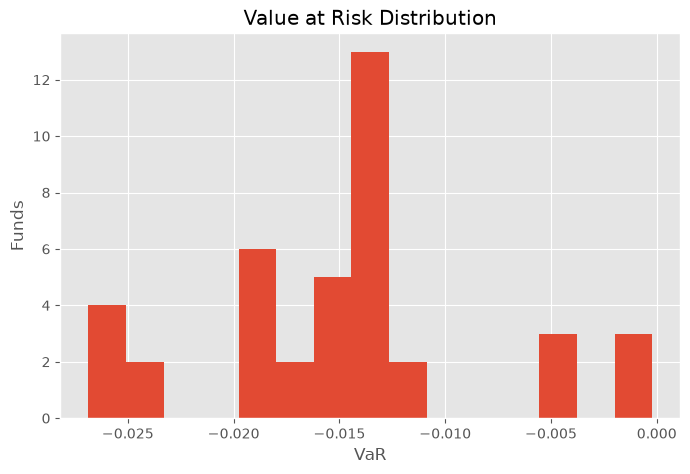

In [16]:
plt.figure(figsize=(8,5))

plt.hist(var95, bins=15)

plt.title("Value at Risk Distribution")

plt.xlabel("VaR")

plt.ylabel("Funds")

plt.show()

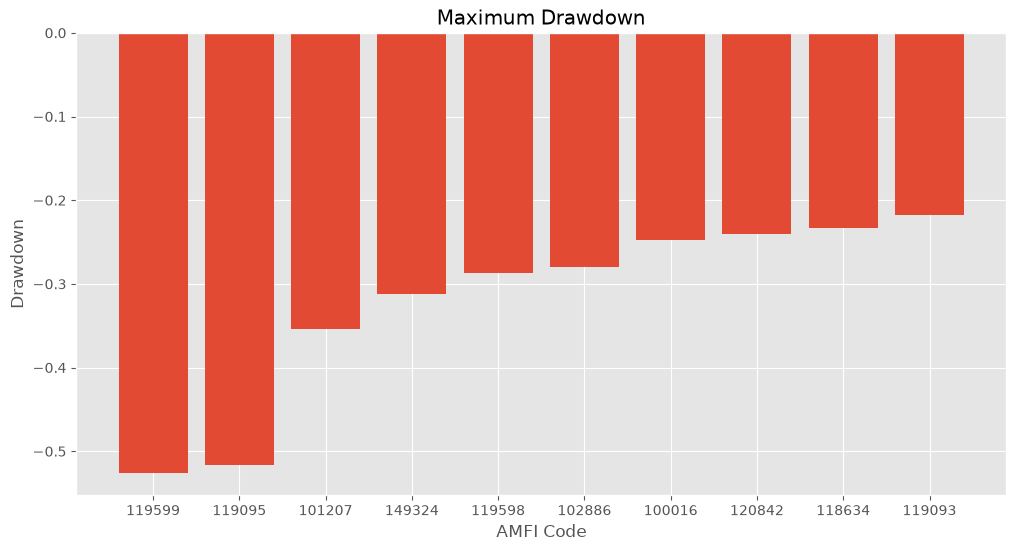

In [17]:
top_drawdown = max_drawdown.sort_values().head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_drawdown.index.astype(str),
    top_drawdown.values
)

plt.title("Maximum Drawdown")

plt.xlabel("AMFI Code")

plt.ylabel("Drawdown")

plt.show()

In [18]:
sharpe.to_csv(
    "../reports/fund_sharpe_ranks.csv"
)

summary = pd.DataFrame({
    "VaR95": var95,
    "Max Drawdown": max_drawdown
})

summary.to_csv(
    "../reports/var_drawdown_summary.csv"
)

print("CSV files exported successfully!")

CSV files exported successfully!
